# Base Strategy Walkthrough

This notebook demonstrates the execution strategy framework. All logic lives in `utils/`:

| Module | What it does |
|--------|-------------|
| `config.py` | Default experiment settings (grid ranges, train/test split, etc.) |
| `preprocessing.py` | Load CSVs, detect penny vs. wide archetype, compute TWAP |
| `signals.py` | Pluggable signal functions (OI, weighted OI, etc.) + diagnostic plots |
| `strategy.py` | `BaseStrategy` class, grid search, `run_experiment()` one-liner |
| `evaluation.py` | Backtest harness, results tables, `compare_strategies()` |

**To add a new strategy:** subclass `BaseStrategy`, implement `decide()`, and call `run_experiment()`. See Section 4 for an example.

## 1. Setup & Data Loading

In [38]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (12, 5), 'font.size': 11})

from utils.config import DEFAULT_CONFIG
from utils.preprocessing import load_all_stocks, train_test_split
from utils.signals import add_horizon_columns, plot_edge_vs_imbalance
from utils.strategy import OIThresholdStrategy, TimeVaryingOIThresholdStrategy, TodPennnyOIThresholdStrategy, run_experiment
from utils.evaluation import print_results, plot_results, compare_strategies

config = DEFAULT_CONFIG.copy()

data, frames, archetypes = load_all_stocks(config)

print(f"Total ticks: {len(data):,}")
for t in config['stocks']:
    n = data.loc[data['ticker'] == t, 'minute_start'].nunique()
    med = frames[t]['spread'].median()
    print(f"  {t}: {archetypes[t]:6s}  ({n} min, median spread = ${med:.4f})")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Total ticks: 1,149,529
  INTC: penny   (270 min, median spread = $0.0100)
  MSFT: penny   (270 min, median spread = $0.0100)
  AMZN: wide    (270 min, median spread = $0.1400)
  GOOG: wide    (270 min, median spread = $0.3000)


## 2. Signal Analysis

Does OI predict future price movement? Plot mean mid-price change vs. OI at multiple horizons.

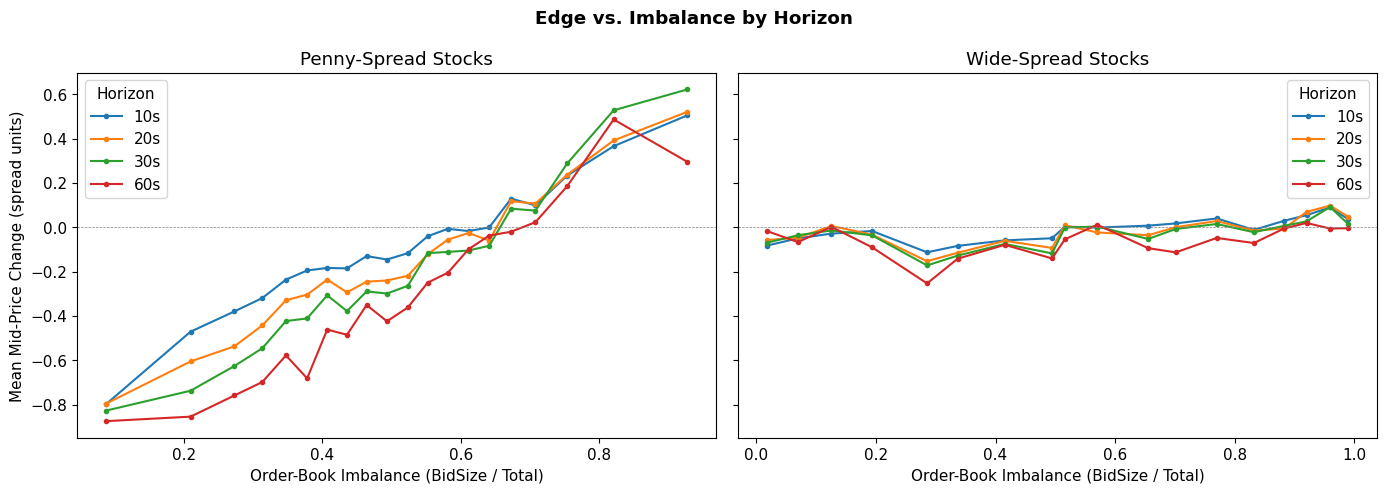

In [39]:
add_horizon_columns(data, config)
plot_edge_vs_imbalance(data, config)

## 3. Run the Base Strategy (OI Threshold)

`run_experiment()` handles everything: load data, fit parameters via grid search, backtest on held-out data.

In [40]:
oi_results = run_experiment(OIThresholdStrategy, config, signal_fn='oi')

Running experiment: OI Threshold (signal=oi)
  INTC: penny
  MSFT: penny
  AMZN: wide
  GOOG: wide
  Train: 189 min, Test: 81 min
  Fitting parameters...
    penny: theta_imb=0.9500, theta_spread=0.0116
    wide: theta_imb=0.5200, theta_spread=0.1566
  Backtesting...


Mean Improvement over TWAP ($)
  Penny  (n= 324, win_rate=77.2%)  OI Threshold: $+0.005634  First Tick: $+0.000695  Last Tick: $+0.000695
  Wide   (n= 324, win_rate=62.3%)  OI Threshold: $+0.039890  First Tick: $+0.004427  Last Tick: $+0.004828
  All    (n= 648, win_rate=69.8%)  OI Threshold: $+0.022762  First Tick: $+0.002561  Last Tick: $+0.002762

Mean Improvement (spread units)

  Penny (median spread = $0.0100):
    OI Threshold        : +0.5634 spread units
    First Tick          : +0.0695 spread units
    Last Tick           : +0.0695 spread units

  Wide (median spread = $0.1600):
    OI Threshold        : +0.2493 spread units
    First Tick          : +0.0277 spread units
    Last Tick           : +0.0302 spread units


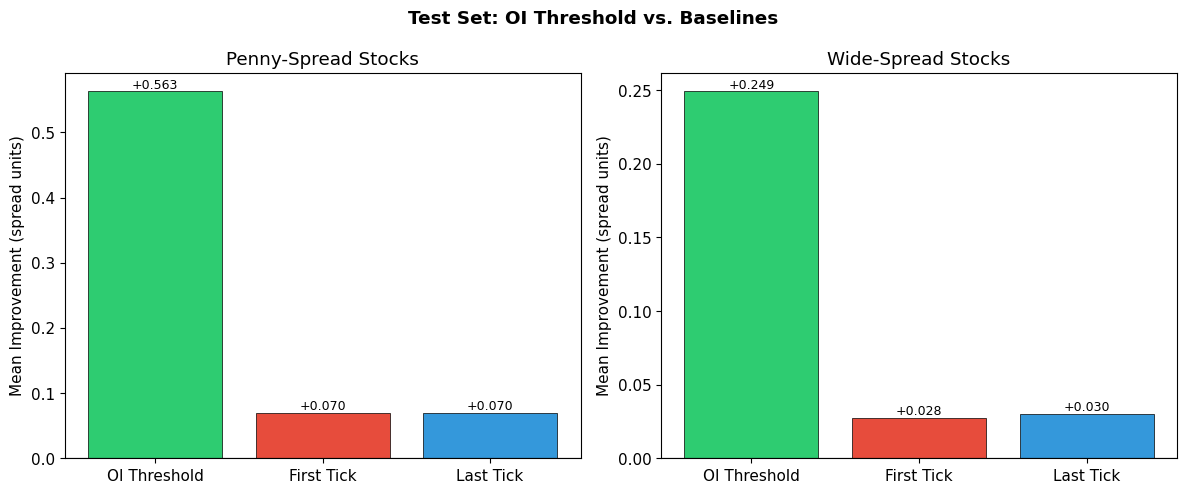

In [41]:
print_results(oi_results['test_all'], strategy_name='OI Threshold')
plot_results(oi_results['test_all'], strategy_name='OI Threshold')

## 4. How to Add a New Strategy

Subclass `BaseStrategy`, implement `decide()` and `param_grid()`, then call `run_experiment()`. Here's an example using the **weighted 5-level OI** signal instead of level-1 OI:

In [42]:
# Same strategy logic, just swap the signal to weighted 5-level OI
weighted_results = run_experiment(OIThresholdStrategy, config, signal_fn='weighted_oi')

Running experiment: OI Threshold (signal=weighted_oi)
  INTC: penny
  MSFT: penny
  AMZN: wide
  GOOG: wide
  Train: 189 min, Test: 81 min
  Fitting parameters...
    penny: theta_imb=0.5793, theta_spread=0.0116
    wide: theta_imb=0.5719, theta_spread=0.1684
  Backtesting...


## 5. Compare Strategies

`compare_strategies()` puts multiple experiment results side by side — mean improvement, std, win rate — with a bar chart.

In [43]:
# comparison = compare_strategies([
#     ('OI (level 1)', oi_results),
#     ('Weighted OI (5-level)', weighted_results),
# ])

## Quick Reference: Adding Your Own Strategy

```python
from utils.strategy import BaseStrategy, run_experiment
from utils.config import DEFAULT_CONFIG
import numpy as np

class MyStrategy(BaseStrategy):
    name = 'My Strategy'

    def decide(self, signal, spread, side):
        """Return tick index to execute, or None for last-tick fallback."""
        for i in range(len(signal)):
            if signal[i] > self.params['my_threshold']:
                return i
        return None

    @classmethod
    def param_grid(cls, archetype):
        return {'my_threshold': np.linspace(0.5, 0.95, 20)}

results = run_experiment(MyStrategy, DEFAULT_CONFIG, signal_fn='oi')
```

To add a new **signal**, add a function to `utils/signals.py` and register it in `SIGNAL_REGISTRY`.

## 6. Testing Teammate's Strategies (time of day comparison) & time of day for only penny

Using the adapter to run these strategies through the same eval pipeline.

In [44]:
time_varying_results = run_experiment(TimeVaryingOIThresholdStrategy, config, signal_fn='oi')
todpennny_results = run_experiment(TodPennnyOIThresholdStrategy, config, signal_fn='oi')

Running experiment: TimeOfDay (signal=oi)
  INTC: penny
  MSFT: penny
  AMZN: wide
  GOOG: wide
  Train: 189 min, Test: 81 min
  Fitting parameters...
    ('penny', 570): theta_imb=0.9812, theta_spread=0.0161
    ('penny', 571): theta_imb=0.9786, theta_spread=0.0157
    ('penny', 572): theta_imb=0.9719, theta_spread=0.0147
    ('penny', 573): theta_imb=0.9667, theta_spread=0.0140
    ('penny', 574): theta_imb=0.9646, theta_spread=0.0137
    ('penny', 575): theta_imb=0.9656, theta_spread=0.0138
    ('penny', 576): theta_imb=0.9673, theta_spread=0.0141
    ('penny', 577): theta_imb=0.9646, theta_spread=0.0137
    ('penny', 578): theta_imb=0.9669, theta_spread=0.0140
    ('penny', 579): theta_imb=0.9641, theta_spread=0.0136
    ('penny', 580): theta_imb=0.9646, theta_spread=0.0137
    ('penny', 581): theta_imb=0.9606, theta_spread=0.0131
    ('penny', 582): theta_imb=0.9592, theta_spread=0.0129
    ('penny', 583): theta_imb=0.9537, theta_spread=0.0121
    ('penny', 584): theta_imb=0.9511,

STRATEGY COMPARISON

  Penny:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    OI Threshold (baseline)        +0.5634       0.5791      77.2%
    Time-Varying OI Threshold      +0.6097       0.5546      79.3%
    Weighted OI (5-level)          +0.3689       0.6982      65.1%
    TimeOfDay-Penny                +0.6097       0.5546      79.3%

  Wide:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    OI Threshold (baseline)        +0.2493       0.6677      62.3%
    Time-Varying OI Threshold      +0.1691       0.6330      60.8%
    Weighted OI (5-level)          +0.1585       0.6544      55.6%
    TimeOfDay-Penny                +0.2493       0.6677      62.3%

  All:
    Strategy                    Mean (spr)    Std (spr)   Win Rate
    ------------------------- ------------ ------------ ----------
    OI Threshol

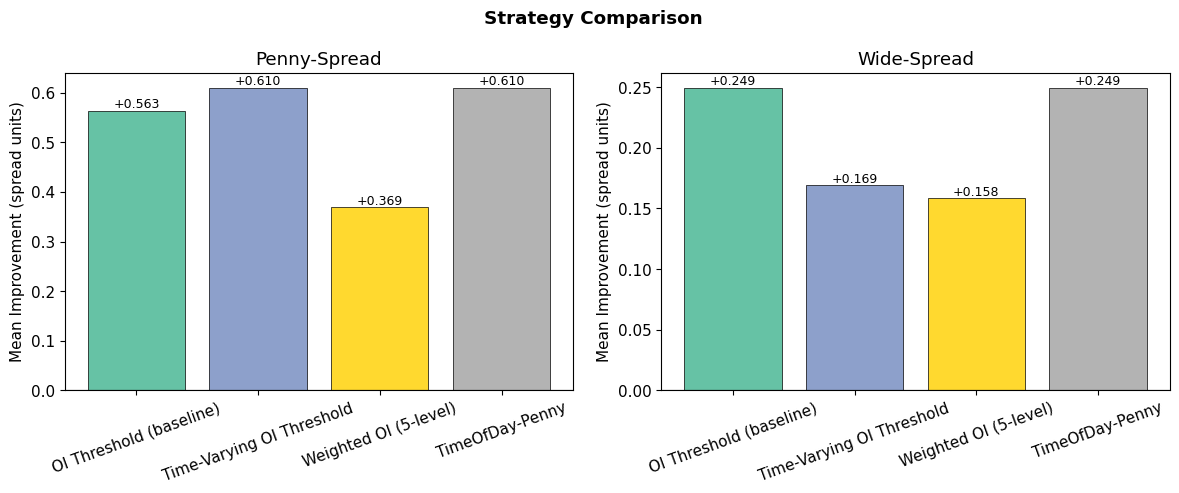

,strategy,archetype,mean_improvement_$,mean_improvement_spreads,std_spreads,win_rate,n_minutes
0,OI Threshold (baseline),penny,0.005634,0.563358,0.579121,0.771605,324
1,OI Threshold (baseline),wide,0.039890,0.249313,0.667747,0.623457,324
2,OI Threshold (baseline),all,0.022762,0.505819,1.722629,0.697531,648
3,Time-Varying OI Threshold,penny,0.006097,0.609654,0.554583,0.793210,324
4,Time-Varying OI Threshold,wide,0.027051,0.169066,0.633024,0.608025,324
5,Time-Varying OI Threshold,all,0.016574,0.368302,1.609628,0.700617,648
6,Weighted OI (5-level),penny,0.003689,0.368913,0.698175,0.651235,324
7,Weighted OI (5-level),wide,0.025353,0.158457,0.654401,0.555556,324
8,Weighted OI (5-level),all,0.014521,0.322691,1.665162,0.603395,648
9,TimeOfDay-Penny,penny,0.006097,0.609654,0.554583,0.793210,324


In [45]:
# Compare everything side by side against your baseline
compare_strategies([
    ('OI Threshold (baseline)', oi_results),       # already computed in Section 3
    ('Time-Varying OI Threshold', time_varying_results),
    ('Weighted OI (5-level)', weighted_results),
    ('TimeOfDay-Penny', todpennny_results),
])
